In [1]:

# STEP 1: IMPORT LIBRARIES
import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import LabelEncoder

from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay

In [2]:
# DOWNLOAD MOVIE GENRE DATASET FROM KAGGLE


# 1️⃣ Make sure your kaggle.json is uploaded to Colab
from google.colab import files
uploaded = files.upload()  # Upload kaggle.json

# 2️⃣ Move kaggle.json to the correct folder for Kaggle API
import os, shutil
os.makedirs(os.path.expanduser("~/.kaggle"), exist_ok=True)
shutil.move("kaggle.json", os.path.expanduser("~/.kaggle/kaggle.json"))
!chmod 600 ~/.kaggle/kaggle.json

Saving kaggle.json to kaggle.json


In [7]:



# 3️⃣ Download the dataset from Kaggle
!kaggle datasets download -d hijest/genre-classification-dataset-imdb -p ./genre_data

# 4️⃣ Unzip the downloaded dataset into a folder
!unzip -o ./genre_data/genre-classification-dataset-imdb.zip -d ./genre_data

# 5️⃣ Load the data into a dataframe
import pandas as pd

# The file inside zip is usually 'train_data.txt'
df = pd.read_csv("./genre_data/Genre Classification Dataset/train_data.txt", sep=":::", engine="python", names=["title", "genre", "plot"])


Saving kaggle.json to kaggle.json
Dataset URL: https://www.kaggle.com/datasets/hijest/genre-classification-dataset-imdb
License(s): other
genre-classification-dataset-imdb.zip: Skipping, found more recently modified local copy (use --force to force download)
Archive:  ./genre_data/genre-classification-dataset-imdb.zip
  inflating: ./genre_data/Genre Classification Dataset/description.txt  
  inflating: ./genre_data/Genre Classification Dataset/test_data.txt  
  inflating: ./genre_data/Genre Classification Dataset/test_data_solution.txt  
  inflating: ./genre_data/Genre Classification Dataset/train_data.txt  


In [9]:
# STEP 4: TEXT PREPROCESSING
def preprocess_text(text):
    text = text.lower()
    text = re.sub(r"[^a-zA-Z\s]", "", text)
    return text

df["plot"] = df["plot"].apply(preprocess_text)

In [10]:

# STEP 5: ENCODE GENRE LABELS
label_encoder = LabelEncoder()
df["genre_encoded"] = label_encoder.fit_transform(df["genre"])


In [11]:
# STEP 6: TF-IDF FEATURE EXTRACTION
tfidf = TfidfVectorizer(max_features=5000, stop_words="english")
X = tfidf.fit_transform(df["plot"])
y = df["genre_encoded"]

In [12]:
# STEP 7: TRAIN-TEST SPLIT
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [14]:
# STEP 8: TRAIN MULTIPLE MODELS
models = {
    "Naive Bayes": MultinomialNB(),
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "SVM": LinearSVC()
}

results = {}

for name, model in models.items():
    print(f"\nTraining {name}...")
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    results[name] = model

    print("Accuracy:", round(accuracy_score(y_test, y_pred), 4))
    print(classification_report(y_test, y_pred, target_names=label_encoder.classes_))


Training Naive Bayes...
Accuracy: 0.5226
               precision    recall  f1-score   support

      action        0.56      0.08      0.13       263
       adult        0.50      0.03      0.06       118
   adventure        0.78      0.05      0.09       155
   animation        0.00      0.00      0.00       100
   biography        0.00      0.00      0.00        53
      comedy        0.50      0.43      0.47      1490
       crime        0.00      0.00      0.00       101
 documentary        0.57      0.89      0.70      2619
       drama        0.46      0.82      0.59      2723
      family        0.00      0.00      0.00       157
     fantasy        0.00      0.00      0.00        65
   game-show        1.00      0.21      0.34        39
     history        0.00      0.00      0.00        49
      horror        0.74      0.36      0.49       441
       music        0.79      0.10      0.18       146
     musical        0.00      0.00      0.00        55
     mystery        0.

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


Accuracy: 0.5776
               precision    recall  f1-score   support

      action        0.51      0.26      0.34       263
       adult        0.82      0.31      0.44       118
   adventure        0.68      0.14      0.23       155
   animation        0.56      0.09      0.16       100
   biography        0.00      0.00      0.00        53
      comedy        0.52      0.60      0.56      1490
       crime        0.17      0.01      0.02       101
 documentary        0.66      0.86      0.74      2619
       drama        0.54      0.76      0.63      2723
      family        0.52      0.10      0.16       157
     fantasy        0.00      0.00      0.00        65
   game-show        1.00      0.44      0.61        39
     history        0.00      0.00      0.00        49
      horror        0.65      0.56      0.60       441
       music        0.70      0.39      0.50       146
     musical        0.50      0.02      0.04        55
     mystery        0.50      0.02      0.03   

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


Accuracy: 0.565
               precision    recall  f1-score   support

      action        0.38      0.34      0.36       263
       adult        0.62      0.43      0.51       118
   adventure        0.35      0.19      0.24       155
   animation        0.32      0.19      0.24       100
   biography        0.00      0.00      0.00        53
      comedy        0.53      0.57      0.55      1490
       crime        0.24      0.06      0.10       101
 documentary        0.69      0.81      0.74      2619
       drama        0.56      0.69      0.62      2723
      family        0.34      0.17      0.22       157
     fantasy        0.12      0.05      0.07        65
   game-show        0.86      0.62      0.72        39
     history        0.40      0.04      0.07        49
      horror        0.57      0.61      0.59       441
       music        0.55      0.40      0.47       146
     musical        0.25      0.05      0.09        55
     mystery        0.19      0.05      0.07    

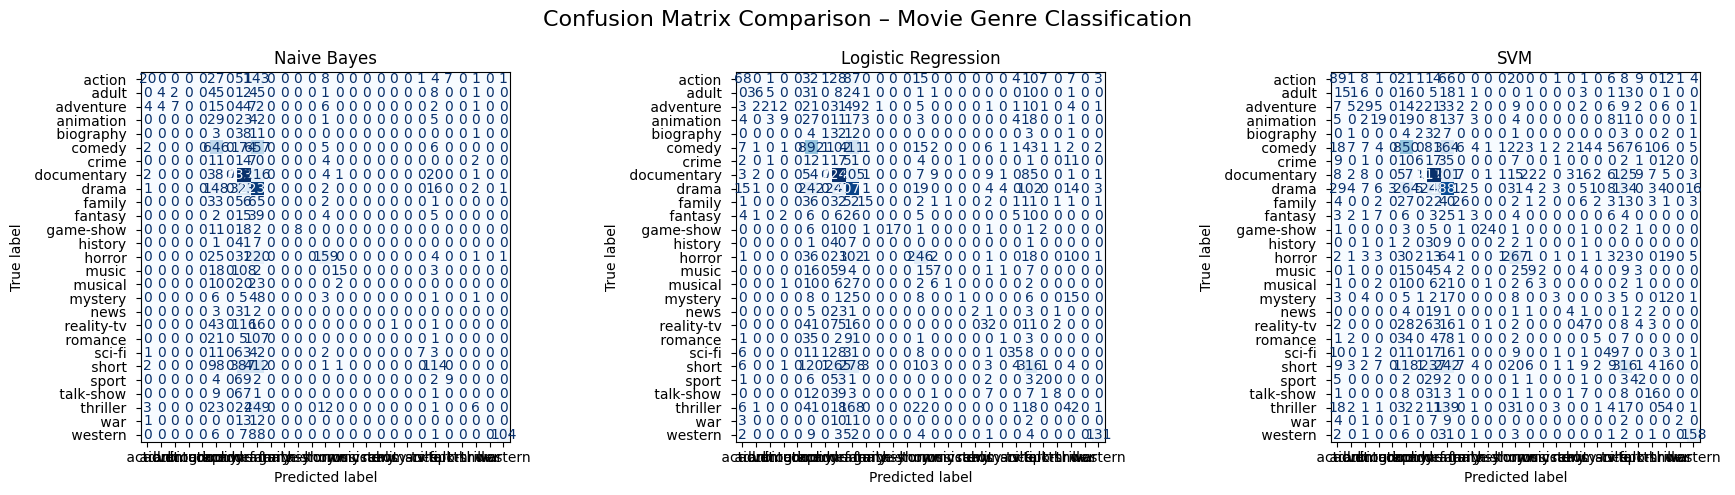

In [15]:
# STEP 9: CONFUSION MATRIX COMPARISON FOR ALL MODELS
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, (name, model) in zip(axes, results.items()):
    y_pred = model.predict(X_test)
    cm = confusion_matrix(y_test, y_pred)

    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=label_encoder.classes_
    )
    disp.plot(ax=ax, cmap="Blues", colorbar=False)
    ax.set_title(name)

plt.suptitle("Confusion Matrix Comparison – Movie Genre Classification", fontsize=16)
plt.tight_layout()
plt.show()

In [17]:

# STEP 10: FUNCTION TO TEST YOUR OWN MOVIE PLOT
def predict_genre(plot, model_name="SVM"):
    plot = preprocess_text(plot)
    vectorized = tfidf.transform([plot])
    model = results[model_name]
    pred = model.predict(vectorized)[0]
    return label_encoder.inverse_transform([pred])[0]

In [18]:
# STEP 11: TEST USER INPUT
while True:
    plot_input = input("\nEnter Movie Plot (type 'exit' to quit): ")
    if plot_input.lower() == "exit":
        print("Exiting prediction mode.")
        break
    genre_pred = predict_genre(plot_input)
    print("Predicted Genre:", genre_pred)


Enter Movie Plot (type 'exit' to quit):      "A young lion cub struggles to claim his rightful place as king after the sudden death of his father, learning important life lessons along the way.
Predicted Genre:  drama 

Enter Movie Plot (type 'exit' to quit): v
Predicted Genre:  short 

Enter Movie Plot (type 'exit' to quit):     "An investigative journalist uncovers a government conspiracy while trying to expose a high-profile crime syndicate.
Predicted Genre:  documentary 

Enter Movie Plot (type 'exit' to quit):     "An investigative journalist uncovers a government conspiracy while trying to expose a high-profile crime syndicate.
Predicted Genre:  documentary 

Enter Movie Plot (type 'exit' to quit): exit
Exiting prediction mode.


In [ ]:
movie_plots = [
    # Fantasy / Adventure
    "A young wizard discovers his magical powers and attends a school of wizardry, where he must fight dark forces to save his friends and the magical world.",
    "A hobbit sets out on a perilous journey to destroy a powerful ring that threatens to enslave all of Middle-earth.",

    # Action / Thriller
    "A retired spy is forced back into action when a dangerous criminal organization kidnaps his family. He must use his skills to save them and stop a global threat.",
    "An elite team of mercenaries must steal a mysterious artifact from a heavily guarded facility, facing deadly traps and betrayal.",

    # Romance / Drama
    "Two strangers meet by chance on a train and fall in love despite coming from very different worlds, facing challenges that test their relationship.",
    "A young couple struggles to maintain their love while dealing with family expectations and personal ambitions in a bustling city.",

    # Horror
    "A group of friends travel to a remote cabin in the woods, only to encounter a terrifying supernatural presence that hunts them one by one.",
    "A family moves into a new home, unaware that it is haunted by vengeful spirits seeking justice for past wrongs.",

    # Comedy
    "A clumsy chef accidentally ruins a famous restaurant’s big event, leading to a series of hilarious mishaps as he tries to fix everything before the night ends.",
    "Three best friends start a business with zero experience, causing chaos and laughter as they try to keep it afloat.",

    # Sci-Fi / Adventure
    "In the year 2150, a team of astronauts travels to a distant planet to find a new home for humanity, but they discover strange life forms that threaten their mission.",
    "A scientist invents a time machine and accidentally disrupts history, forcing a race against time to fix the timeline.",

    # Mystery / Crime
    "A brilliant detective must solve a series of murders in a small town, uncovering dark secrets hidden behind the quiet streets and friendly neighbors.",
    "An investigative journalist uncovers a government conspiracy while trying to expose a high-profile crime syndicate.",

    # Animated / Family
    "A young lion cub struggles to claim his rightful place as king after the sudden death of his father, learning important life lessons along the way.",
    "A group of toy characters come to life and embark on an adventure to save their owner from danger.",

    # Musical / Drama
    "An aspiring singer moves to a big city to chase her dreams, overcoming obstacles in love, friendship, and family while trying to make it on stage.",
    "A group of high school students form a choir and compete in a national competition, discovering themselves along the way.",

    # Historical / War
    "During World War II, a young soldier navigates the horrors of battle, forming bonds with his comrades while facing life-and-death decisions on the front lines.",
    "A queen fights to save her kingdom from invading forces while balancing political intrigue and personal sacrifices.",

    # Superhero / Action
    "A young man gains superpowers after a lab accident and must protect his city from a powerful villain threatening global chaos.",
    "A team of superheroes comes together to stop a villainous organization from destroying the world.",

    # Thriller / Mystery
    "A kidnapped heiress must outsmart her captor while a detective races against time to rescue her before it’s too late.",
    "A psychologist investigates a series of bizarre murders, discovering a shocking connection between the victims.",

    # Adventure / Family
    "Three siblings find a magical map that leads them on a quest through dangerous jungles and hidden caves to find a lost treasure.",
    "A young boy discovers a secret island inhabited by mythical creatures and goes on a journey to protect them from poachers."
]
